# Nationwide validation and calibration of evapotranspiration in the NPS Water Balance Model

**Code companion to `reports/pet_comparison_report.html`.**

This notebook reproduces every table and figure in the narrative report, with the
actual code visible and executable, instead of static HTML/embedded images. It is
read-only with respect to Earth Engine and the WBM itself — everything here reads
cached outputs already produced by notebooks 02 (OpenET/gridMET), 03 (default Oudin
WBM run), 04 (per-site/per-ecosystem-calibrated Oudin), 06 (default Penman-Monteith
WBM run), and 07 (per-site/per-ecosystem-Kc-calibrated Penman-Monteith).

Six WBM AET configurations are compared throughout:

| key | configuration |
|---|---|
| `oudin` | Oudin (default, uncalibrated) |
| `oudin_cal` | Oudin (per-site calibrated) |
| `oudin_eco_cal` | Oudin (per-ecosystem calibrated) |
| `pm` | Penman-Monteith (default, uncalibrated) |
| `pm_cal` | Penman-Monteith (per-site Kc calibrated) |
| `pm_eco_cal` | Penman-Monteith (per-ecosystem Kc calibrated) |

**Part 1** (Tables 1&ndash;4, Figs. 2&ndash;5) evaluates AET accuracy against OpenET
(held-out 2022&ndash;2023) and flux towers (full 2016&ndash;2023 record). **Part 2**
(Tables 5&ndash;6, Figs. 6&ndash;9) evaluates the water-balance and seasonal-runoff
consequences of AET method choice.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
from scipy.stats import wilcoxon

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

VARIANTS = ["oudin", "oudin_cal", "oudin_eco_cal", "pm", "pm_cal", "pm_eco_cal"]
VARIANT_LABELS = {
    "oudin":         "Oudin (default)",
    "oudin_cal":     "Oudin (per-site calibrated)",
    "oudin_eco_cal": "Oudin (per-ecosystem calibrated)",
    "pm":            "Penman-Monteith (default)",
    "pm_cal":        "Penman-Monteith (per-site Kc calibrated)",
    "pm_eco_cal":    "Penman-Monteith (per-ecosystem Kc calibrated)",
}
VARIANT_COLORS = {
    "oudin":         "darkblue",
    "oudin_cal":     "seagreen",
    "oudin_eco_cal": "goldenrod",
    "pm":            "tomato",
    "pm_cal":        "mediumpurple",
    "pm_eco_cal":    "slategrey",
}
print("Imports OK -- this notebook only reads cached CSVs, no GEE/WBM run needed.")

Imports OK -- this notebook only reads cached CSVs, no GEE/WBM run needed.


## Part 1 — AET accuracy vs. OpenET and flux towers

### Load cached outputs (notebooks 02/03/04/06/07)

Reconstructs the same `combined` / `combined_test` / `combined_ts` monthly-matched
dataframes notebook 08 builds, so every accuracy table/figure below can be computed
from first principles rather than trusting a pre-computed metrics CSV.

In [2]:
flux_towers = pd.read_csv("../Data/geo_data/flux_towers.csv")

openet_gridcell_df = pd.read_csv(
    "../Data/open_et_gridcell/openet_gridcell_timeseries.csv", parse_dates=["date"]
)

wbm_results_oudin = pd.read_csv(
    "../Data/gridmet_cache/wbm_results_flux_towers_2016_2023.csv", parse_dates=["date"]
)
wbm_results_pm = pd.read_csv(
    "../Data/gridmet_cache/wbm_results_penman_monteith.csv", parse_dates=["date"]
)
TO_INCHES = True  # repo-wide convention (see notebooks 03/06/07)

with open("../Data/gridmet_cache/last_objective.txt") as f:
    CAL_OBJECTIVE = f.read().strip()
with open("../Data/gridmet_cache/last_objective_pm.txt") as f:
    CAL_OBJECTIVE_PM = f.read().strip()

wbm_monthly_oudin_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_site_cal_{CAL_OBJECTIVE}.csv", parse_dates=["date_monthly"]
)
wbm_monthly_oudin_eco_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_ecosystem_cal_{CAL_OBJECTIVE}.csv", parse_dates=["date_monthly"]
)
wbm_monthly_pm_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_site_cal_pm_{CAL_OBJECTIVE_PM}.csv", parse_dates=["date_monthly"]
)
wbm_monthly_pm_eco_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_ecosystem_cal_pm_{CAL_OBJECTIVE_PM}.csv", parse_dates=["date_monthly"]
)

# flux_monthly is a cheap local read (no GEE call) -- rebuilt the same way notebooks 04/08 do.
flux_frames = []
for row in flux_towers.itertuples():
    fpath = f"../Data/flux_ET_dataset/monthly_data_files/{row.site}_monthly_data.csv"
    if not os.path.exists(fpath):
        continue
    _fdf = pd.read_csv(fpath, parse_dates=["date"])
    _fdf = _fdf[_fdf["date"] >= "2016-01-01"]
    _fdf["site"] = row.site
    flux_frames.append(_fdf)
flux_monthly = pd.concat(flux_frames, ignore_index=True).sort_values(["site", "date"]).reset_index(drop=True)

CAL_START, CAL_END = "2016-01-01", "2021-12-31"
TEST_START, TEST_END = "2022-01-01", "2023-12-31"

print(f"wbm_results_oudin : {wbm_results_oudin.shape}")
print(f"wbm_results_pm    : {wbm_results_pm.shape}")
print(f"flux_monthly      : {flux_monthly.shape}")
print(f"Objectives        : Oudin={CAL_OBJECTIVE}  PM={CAL_OBJECTIVE_PM}")

wbm_results_oudin : (236601, 25)
wbm_results_pm    : (236601, 25)
flux_monthly      : (2550, 183)
Objectives        : Oudin=peak_nse  PM=peak_nse


In [3]:
FLUX_COLS  = ["ppt_mm", "RAIN", "SNOW", "MELT", "AET", "RUNOFF", "D"]
STATE_COLS = ["SOIL", "PACK", "tmean_C"]

def to_monthly(df, flux_cols=FLUX_COLS, state_cols=STATE_COLS):
    """Aggregate daily WBM output to monthly (sum fluxes, mean states)."""
    agg_dict = {c: "sum" for c in flux_cols if c in df.columns}
    agg_dict.update({c: "mean" for c in state_cols if c in df.columns})
    return (
        df.assign(date_monthly=lambda d: pd.to_datetime(d["date"].dt.to_period("M").dt.to_timestamp()))
        .groupby(["site", "ecosystem", "state", "date_monthly"], as_index=False)
        .agg(agg_dict)
        .sort_values(["site", "date_monthly"])
        .reset_index(drop=True)
    )

wbm_monthly_oudin = to_monthly(wbm_results_oudin)
wbm_monthly_pm    = to_monthly(wbm_results_pm)
_scale = 25.4 if TO_INCHES else 1.0
wbm_monthly_oudin["aet_oudin_mm"] = wbm_monthly_oudin["AET"] * _scale
wbm_monthly_pm["aet_pm_mm"]       = wbm_monthly_pm["AET"] * _scale

print(f"Oudin monthly : {wbm_monthly_oudin.shape}")
print(f"PM monthly    : {wbm_monthly_pm.shape}")

Oudin monthly : (7776, 15)
PM monthly    : (7776, 15)


In [4]:
def to_month_start(df, date_col="date"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col]).dt.to_period("M").dt.to_timestamp()
    return df

openet_gc_plot = to_month_start(openet_gridcell_df).rename(
    columns={"et_ensemble_mm": "et_ensemble_gc_mm"}
)[["site", "date", "et_ensemble_gc_mm"]]

oudin_plot = wbm_monthly_oudin[["site", "ecosystem", "date_monthly", "aet_oudin_mm"]].rename(columns={"date_monthly": "date"})
oudin_cal_plot = wbm_monthly_oudin_cal[["site", "date_monthly", "aet_mm"]].rename(columns={"date_monthly": "date", "aet_mm": "aet_oudin_cal_mm"})
oudin_eco_cal_plot = wbm_monthly_oudin_eco_cal[["site", "date_monthly", "aet_mm"]].rename(columns={"date_monthly": "date", "aet_mm": "aet_oudin_eco_cal_mm"})
pm_plot = wbm_monthly_pm[["site", "date_monthly", "aet_pm_mm"]].rename(columns={"date_monthly": "date"})
pm_cal_plot = wbm_monthly_pm_cal[["site", "date_monthly", "aet_mm"]].rename(columns={"date_monthly": "date", "aet_mm": "aet_pm_cal_mm"})
pm_eco_cal_plot = wbm_monthly_pm_eco_cal[["site", "date_monthly", "aet_mm"]].rename(columns={"date_monthly": "date", "aet_mm": "aet_pm_eco_cal_mm"})

combined = (
    openet_gc_plot
    .merge(oudin_plot, on=["site", "date"], how="inner")
    .merge(oudin_cal_plot, on=["site", "date"], how="inner")
    .merge(oudin_eco_cal_plot, on=["site", "date"], how="inner")
    .merge(pm_plot, on=["site", "date"], how="inner")
    .merge(pm_cal_plot, on=["site", "date"], how="inner")
    .merge(pm_eco_cal_plot, on=["site", "date"], how="inner")
    .sort_values(["site", "date"]).reset_index(drop=True)
)

flux_plot = to_month_start(flux_monthly[["site", "date", "ET_corr"]].rename(columns={"ET_corr": "aet_flux_mm"}))

combined_ts = (
    openet_gc_plot
    .merge(oudin_plot, on=["site", "date"], how="outer")
    .merge(oudin_cal_plot, on=["site", "date"], how="outer")
    .merge(oudin_eco_cal_plot, on=["site", "date"], how="outer")
    .merge(pm_plot, on=["site", "date"], how="outer")
    .merge(pm_cal_plot, on=["site", "date"], how="outer")
    .merge(pm_eco_cal_plot, on=["site", "date"], how="outer")
    .merge(flux_plot, on=["site", "date"], how="outer")
    .sort_values(["site", "date"]).reset_index(drop=True)
)

combined_test = combined[(combined["date"] >= TEST_START) & (combined["date"] <= TEST_END)].reset_index(drop=True)
eco_lookup = combined[["site", "ecosystem"]].drop_duplicates()

print(f"combined      (full period, 6-way \u2229 OpenET) : {len(combined):,} site-months")
print(f"combined_test (held-out {TEST_START}\u2013{TEST_END})      : {len(combined_test):,} site-months")
print(f"combined_ts   (full period, outer incl. flux)  : {len(combined_ts):,} site-months")

combined      (full period, 6-way ∩ OpenET) : 6,909 site-months
combined_test (held-out 2022-01-01–2023-12-31)      : 1,726 site-months
combined_ts   (full period, outer incl. flux)  : 7,776 site-months


### Table 1 — Robustness of accuracy across sites

Per-site RMSE and R&sup2;, summarized as mean, median, and worst-decile (90th
percentile) — against OpenET on the held-out 2022&ndash;2023 period, and against
flux towers on the full 2016&ndash;2023 record.

In [5]:
def compute_metrics(df, obs_col, pred_col, site_col="site", min_n=6):
    """Per-site slope (through origin), MBE, MAE, RMSE, R2."""
    def _slope(o, p): return np.dot(o, p) / np.dot(o, o)
    def _mbe(o, p):   return float(np.mean(p - o))
    def _mae(o, p):   return float(np.mean(np.abs(p - o)))
    def _rmse(o, p):  return float(np.sqrt(np.mean((p - o) ** 2)))
    def _r2(o, p):
        ss_res = np.sum((o - p) ** 2)
        ss_tot = np.sum((o - np.mean(o)) ** 2)
        return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    records = []
    for site, grp in df.groupby(site_col):
        paired = grp[[obs_col, pred_col]].dropna()
        n = len(paired)
        if n < min_n:
            records.append({"site": site, "n": n, "slope": np.nan, "MBE": np.nan,
                             "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "note": f"insufficient data (n={n})"})
            continue
        obs, pred = paired[obs_col].values, paired[pred_col].values
        records.append({
            "site": site, "n": n,
            "slope": round(_slope(obs, pred), 3), "MBE": round(_mbe(obs, pred), 3),
            "MAE": round(_mae(obs, pred), 3), "RMSE": round(_rmse(obs, pred), 3),
            "R2": round(_r2(obs, pred), 3), "note": "",
        })
    return pd.DataFrame(records).sort_values("site").reset_index(drop=True)


PRED_COL = {
    "oudin": "aet_oudin_mm", "oudin_cal": "aet_oudin_cal_mm", "oudin_eco_cal": "aet_oudin_eco_cal_mm",
    "pm": "aet_pm_mm", "pm_cal": "aet_pm_cal_mm", "pm_eco_cal": "aet_pm_eco_cal_mm",
}

METRICS_VS_OPENET = {k: compute_metrics(combined_test, "et_ensemble_gc_mm", PRED_COL[k]) for k in VARIANTS}
METRICS_VS_FLUX   = {k: compute_metrics(combined_ts, "aet_flux_mm", PRED_COL[k]) for k in VARIANTS}

for k in VARIANTS:
    v_ok = METRICS_VS_OPENET[k][METRICS_VS_OPENET[k]["note"] == ""]
    f_ok = METRICS_VS_FLUX[k][METRICS_VS_FLUX[k]["note"] == ""]
    print(f"{VARIANT_LABELS[k]:48s} vs OpenET n={len(v_ok):3d}  vs Flux n={len(f_ok):3d}")

Oudin (default)                                  vs OpenET n= 72  vs Flux n= 67
Oudin (per-site calibrated)                      vs OpenET n= 72  vs Flux n= 58
Oudin (per-ecosystem calibrated)                 vs OpenET n= 72  vs Flux n= 58
Penman-Monteith (default)                        vs OpenET n= 72  vs Flux n= 67
Penman-Monteith (per-site Kc calibrated)         vs OpenET n= 72  vs Flux n= 58
Penman-Monteith (per-ecosystem Kc calibrated)    vs OpenET n= 72  vs Flux n= 58


In [6]:
def robustness_row(mdf, label, ref):
    valid = mdf[mdf["note"] == ""]
    return {
        "WBM AET variant": label, "Reference": ref, "Sites (n)": len(valid),
        "Mean RMSE": round(valid["RMSE"].mean(), 2), "Median RMSE": round(valid["RMSE"].median(), 2),
        "Worst-decile RMSE": round(valid["RMSE"].quantile(0.9), 2),
        "Mean R2": round(valid["R2"].mean(), 3), "Median R2": round(valid["R2"].median(), 3),
    }

table1_rows = []
for ref, metrics_dict in [("vs. OpenET (held-out)", METRICS_VS_OPENET), ("vs. Flux tower (full period)", METRICS_VS_FLUX)]:
    rows = [robustness_row(metrics_dict[k], VARIANT_LABELS[k], ref) for k in VARIANTS]
    rows.sort(key=lambda r: r["Median RMSE"])
    table1_rows.extend(rows)

table1 = pd.DataFrame(table1_rows)
table1

,WBM AET variant,Reference,Sites (n),Mean RMSE,Median RMSE,Worst-decile RMSE,Mean R2,Median R2
0,Oudin (per-site calibrated),vs. OpenET (held-out),72,36.27,28.60,71.54,-0.726,0.212
1,Penman-Monteith (per-ecosystem Kc calibrated),vs. OpenET (held-out),72,37.04,28.77,71.97,-0.812,0.426
2,Penman-Monteith (per-site Kc calibrated),vs. OpenET (held-out),72,36.79,29.35,71.52,-0.705,0.477
3,Penman-Monteith (default),vs. OpenET (held-out),72,39.93,32.55,72.23,-1.037,0.075
4,Oudin (per-ecosystem calibrated),vs. OpenET (held-out),72,42.57,38.28,72.26,-1.039,-0.269
5,Oudin (default),vs. OpenET (held-out),72,46.64,46.60,76.49,-1.177,-0.732
6,Oudin (per-site calibrated),vs. Flux tower (full period),58,49.07,30.21,114.88,-0.374,-0.070
7,Penman-Monteith (per-site Kc calibrated),vs. Flux tower (full period),58,49.35,30.50,116.46,-0.350,0.194
8,Penman-Monteith (per-ecosystem Kc calibrated),vs. Flux tower (full period),58,49.93,32.48,117.61,-0.399,0.256
9,Penman-Monteith (default),vs. Flux tower (full period),67,50.31,35.94,107.33,-0.472,0.060


### Table 2 — Statistical significance of accuracy differences

Paired Wilcoxon signed-rank tests on per-site RMSE (two-sided). Eleven pairwise
comparisons, tested against both references (22 tests total), Holm&ndash;Bonferroni
corrected.

In [7]:
PAIRS = [
    ("oudin_cal", "oudin"), ("oudin_eco_cal", "oudin"), ("oudin_cal", "oudin_eco_cal"),
    ("pm_cal", "pm"), ("pm_eco_cal", "pm"), ("pm_cal", "pm_eco_cal"),
    ("oudin_cal", "pm"), ("oudin_cal", "pm_cal"),
    ("pm", "oudin_eco_cal"), ("pm_cal", "oudin_eco_cal"), ("pm_eco_cal", "oudin_eco_cal"),
]

def paired_rmse(metrics_dict, a, b):
    da = metrics_dict[a][metrics_dict[a]["note"] == ""][["site", "RMSE"]].rename(columns={"RMSE": a})
    db = metrics_dict[b][metrics_dict[b]["note"] == ""][["site", "RMSE"]].rename(columns={"RMSE": b})
    return da.merge(db, on="site", how="inner")

sig_results = []
for ref_label, metrics_dict in [("vs. OpenET (held-out)", METRICS_VS_OPENET), ("vs. Flux tower (full period)", METRICS_VS_FLUX)]:
    for a, b in PAIRS:
        merged = paired_rmse(metrics_dict, a, b)
        if len(merged) < 5:
            continue
        stat, p = wilcoxon(merged[a], merged[b])
        sig_results.append({
            "Comparison": f"{VARIANT_LABELS[a]} (A) vs. {VARIANT_LABELS[b]} (B)", "Reference": ref_label,
            "Sites (n)": len(merged), "Median RMSE, A": round(merged[a].median(), 2),
            "Median RMSE, B": round(merged[b].median(), 2), "p_raw": p,
        })

table2 = pd.DataFrame(sig_results).sort_values("p_raw").reset_index(drop=True)
m = len(table2)
sig_flags, still_sig = [], True
for i, row in table2.iterrows():
    thresh = 0.05 / (m - i)
    if still_sig and row["p_raw"] <= thresh:
        sig_flags.append(True)
    else:
        still_sig = False
        sig_flags.append(False)
table2["Significant"] = sig_flags
table2["p (Wilcoxon)"] = table2["p_raw"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
table2 = table2.drop(columns=["p_raw"])
table2

,Comparison,Reference,Sites (n),"Median RMSE, A","Median RMSE, B",Significant,p (Wilcoxon)
0,Penman-Monteith (per-site Kc calibrated) (A) v...,vs. OpenET (held-out),72,29.35,32.55,True,<0.001
1,Penman-Monteith (per-site Kc calibrated) (A) v...,vs. OpenET (held-out),72,29.35,38.28,True,<0.001
2,Oudin (per-site calibrated) (A) vs. Oudin (per...,vs. OpenET (held-out),72,28.60,38.28,True,<0.001
3,Oudin (per-site calibrated) (A) vs. Penman-Mon...,vs. OpenET (held-out),72,28.60,32.55,True,<0.001
4,Penman-Monteith (per-ecosystem Kc calibrated) ...,vs. OpenET (held-out),72,28.77,32.55,True,<0.001
5,Penman-Monteith (per-ecosystem Kc calibrated) ...,vs. OpenET (held-out),72,28.77,38.28,True,<0.001
6,Oudin (per-site calibrated) (A) vs. Oudin (def...,vs. OpenET (held-out),72,28.60,46.60,True,<0.001
7,Penman-Monteith (per-site Kc calibrated) (A) v...,vs. Flux tower (full period),58,30.50,36.27,True,<0.001
8,Oudin (per-site calibrated) (A) vs. Oudin (def...,vs. Flux tower (full period),58,30.21,51.14,True,<0.001
9,Penman-Monteith (per-site Kc calibrated) (A) v...,vs. Flux tower (full period),58,30.50,45.97,True,<0.001


### Table 3 — Aggregate error and bias metrics

Per-site regression slope, mean bias error (MBE), mean absolute error (MAE), and
RMSE, averaged across sites with sufficient data.

In [8]:
table3_rows = []
for ref, metrics_dict in [("vs. OpenET (held-out)", METRICS_VS_OPENET), ("vs. Flux tower (full period)", METRICS_VS_FLUX)]:
    for k in VARIANTS:
        valid = metrics_dict[k][metrics_dict[k]["note"] == ""]
        table3_rows.append({
            "WBM AET variant": VARIANT_LABELS[k], "Reference": ref, "Sites (n)": len(valid),
            "Slope": round(valid["slope"].mean(), 3), "MBE (mm/mo)": round(valid["MBE"].mean(), 2),
            "MAE (mm/mo)": round(valid["MAE"].mean(), 2), "RMSE (mm/mo)": round(valid["RMSE"].mean(), 2),
            "R2": round(valid["R2"].mean(), 3),
        })
table3 = pd.DataFrame(table3_rows)
table3

,WBM AET variant,Reference,Sites (n),Slope,MBE (mm/mo),MAE (mm/mo),RMSE (mm/mo),R2
0,Oudin (default),vs. OpenET (held-out),72,0.383,-37.25,38.61,46.64,-1.177
1,Oudin (per-site calibrated),vs. OpenET (held-out),72,0.554,-27.67,30.57,36.27,-0.726
2,Oudin (per-ecosystem calibrated),vs. OpenET (held-out),72,0.529,-27.63,34.25,42.57,-1.039
3,Penman-Monteith (default),vs. OpenET (held-out),72,0.606,-21.03,32.53,39.93,-1.037
4,Penman-Monteith (per-site Kc calibrated),vs. OpenET (held-out),72,0.569,-23.98,30.89,36.79,-0.705
5,Penman-Monteith (per-ecosystem Kc calibrated),vs. OpenET (held-out),72,0.566,-24.62,30.27,37.04,-0.812
6,Oudin (default),vs. Flux tower (full period),67,0.356,-45.58,47.58,59.42,-0.910
7,Oudin (per-site calibrated),vs. Flux tower (full period),58,0.582,-32.99,39.16,49.07,-0.374
8,Oudin (per-ecosystem calibrated),vs. Flux tower (full period),58,0.558,-33.48,43.78,56.04,-0.816
9,Penman-Monteith (default),vs. Flux tower (full period),67,0.731,-18.26,39.44,50.31,-0.472


### Figure 2 — Spatial distribution of the best-matching AET variant

For each of the 72 held-out sites, which of the six WBM AET configurations has
the lowest local RMSE vs. OpenET, and by how much (margin over the runner-up)?

In [9]:
RMSE_COLS = {k: f"RMSE_{k}" for k in VARIANTS}

map_df = None
for k in VARIANTS:
    valid = METRICS_VS_OPENET[k][METRICS_VS_OPENET[k]["note"] == ""][["site", "RMSE"]].rename(columns={"RMSE": RMSE_COLS[k]})
    map_df = valid if map_df is None else map_df.merge(valid, on="site", how="inner")

map_df = map_df.merge(flux_towers[["site", "x", "y", "ecosystem"]], on="site", how="left").dropna(subset=["x", "y"]).reset_index(drop=True)

rmse_cols_list = list(RMSE_COLS.values())
best_col = map_df[rmse_cols_list].idxmin(axis=1)
inv_rmse_cols = {v: k for k, v in RMSE_COLS.items()}
map_df["best_variant"] = best_col.map(inv_rmse_cols)
map_df["best_RMSE"] = map_df[rmse_cols_list].min(axis=1)
sorted_vals = map_df[rmse_cols_list].apply(lambda r: sorted(r.values), axis=1)
map_df["margin"] = sorted_vals.apply(lambda v: v[1] - v[0])

print(f"Sites mapped (held-out {TEST_START}\u2013{TEST_END}): {len(map_df)}")
print("Sites where each variant is locally best:")
print(map_df["best_variant"].map(VARIANT_LABELS).value_counts().to_string())

Sites mapped (held-out 2022-01-01–2023-12-31): 72
Sites where each variant is locally best:
best_variant
Oudin (per-site calibrated)                      26
Penman-Monteith (per-site Kc calibrated)         16
Oudin (default)                                  16
Penman-Monteith (per-ecosystem Kc calibrated)     8
Oudin (per-ecosystem calibrated)                  3
Penman-Monteith (default)                         3


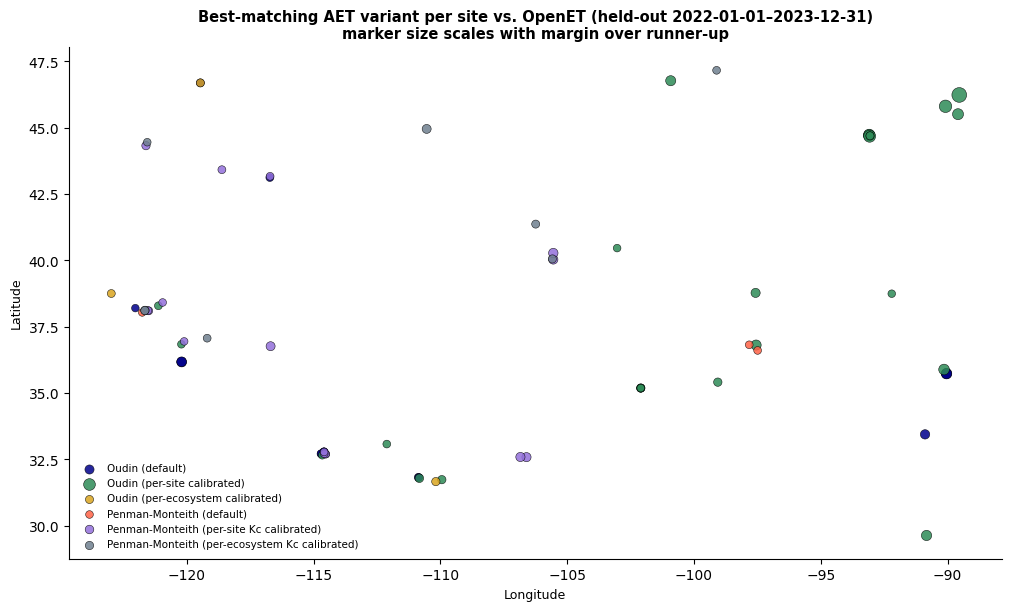

In [10]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

for k in VARIANTS:
    sub = map_df[map_df["best_variant"] == k]
    if sub.empty:
        continue
    ax.scatter(sub["x"], sub["y"], s=30 + sub["margin"] * 12, color=VARIANT_COLORS[k],
               edgecolors="k", linewidths=0.4, alpha=0.85, label=VARIANT_LABELS[k], zorder=3)

ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.set_title(f"Best-matching AET variant per site vs. OpenET (held-out {TEST_START}\u2013{TEST_END})\n"
             "marker size scales with margin over runner-up", fontsize=10.5, fontweight="bold")
ax.legend(fontsize=7.5, frameon=False, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Figure 3 — Site-mean AET scatter, by configuration

One point per site (site-mean AET): held-out vs. OpenET (left panel) and
full-period vs. flux tower (right panel), colored by ecosystem.

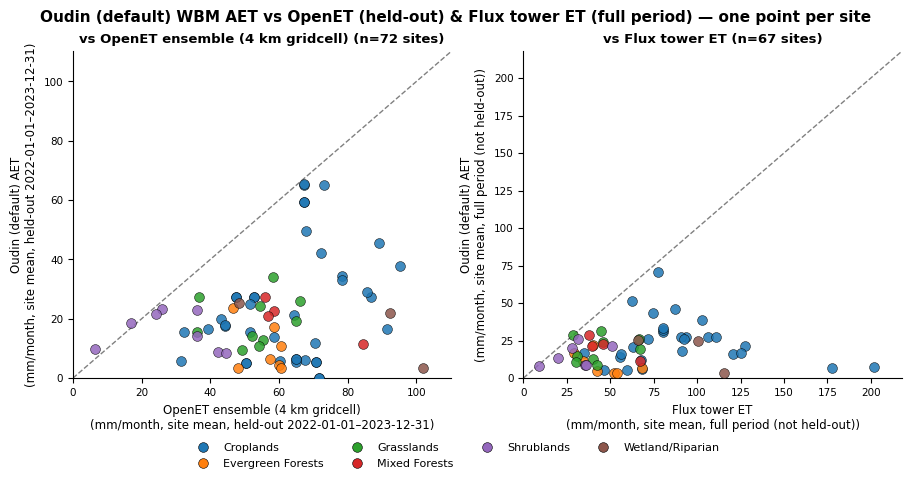

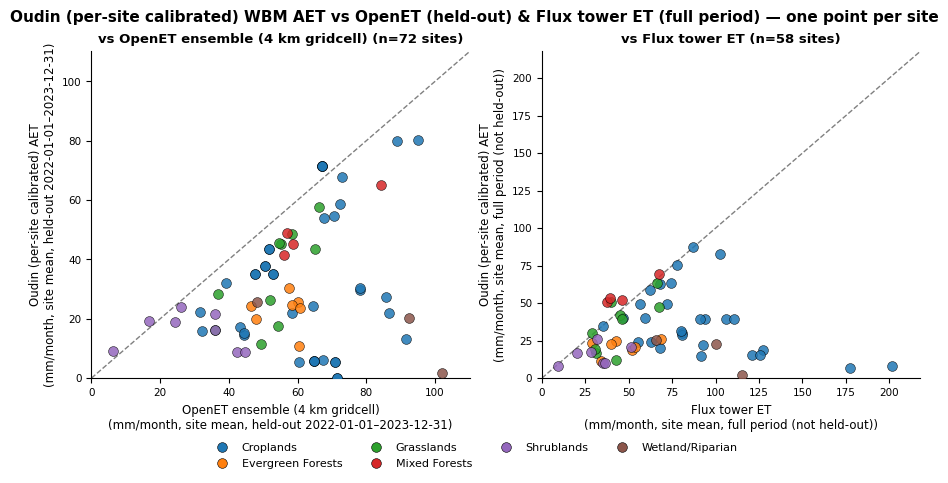

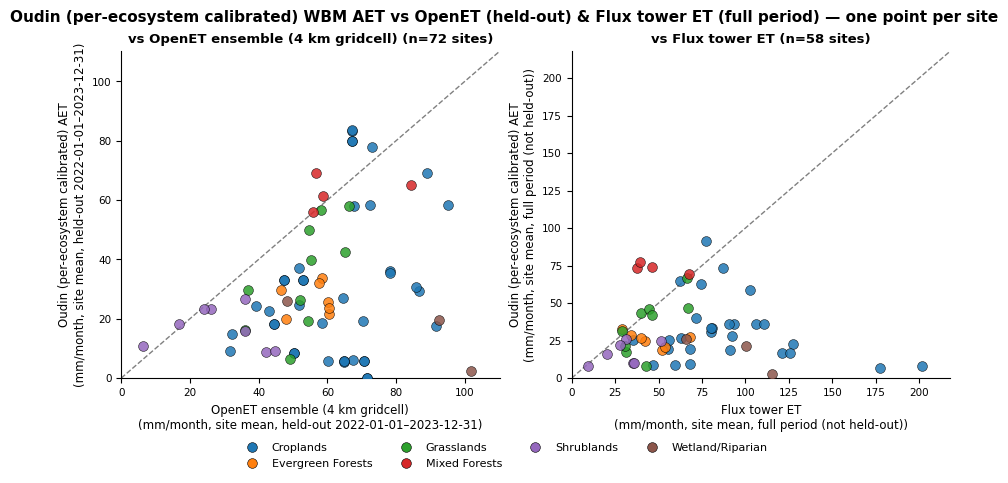

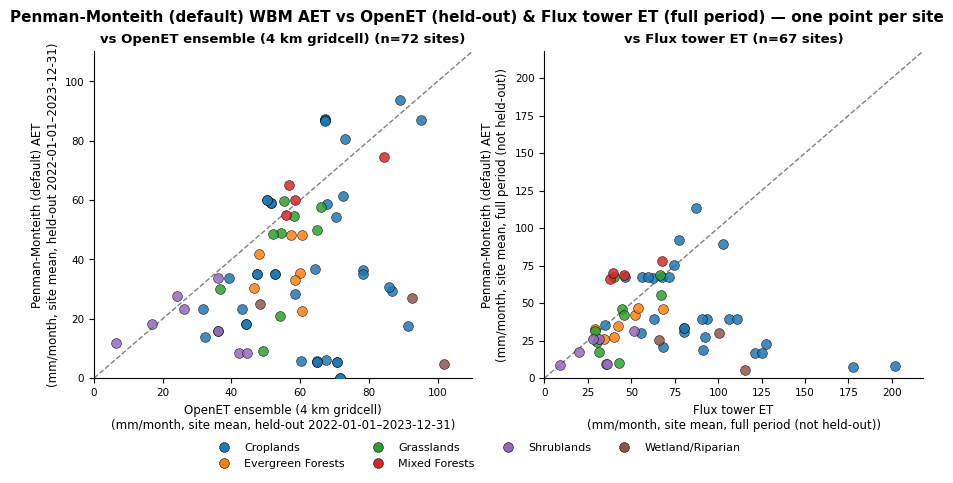

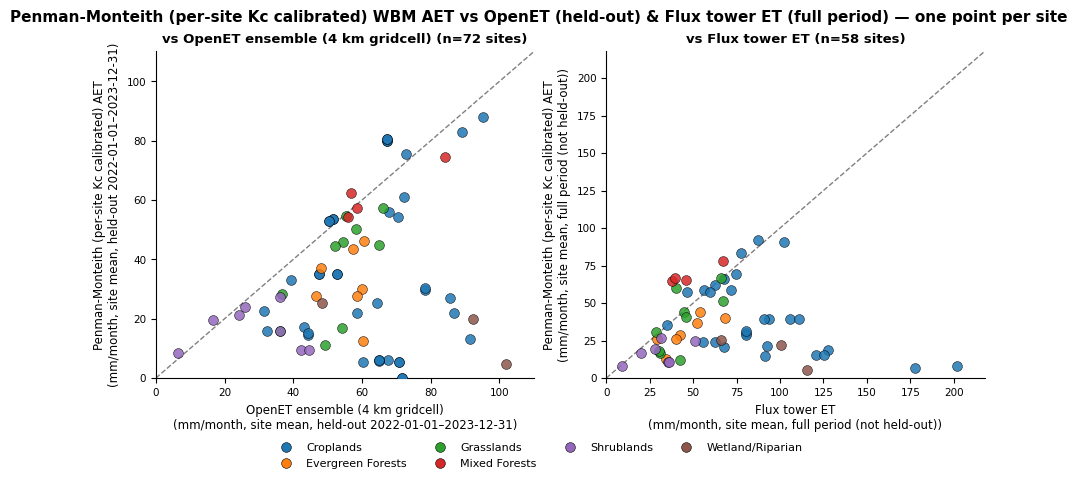

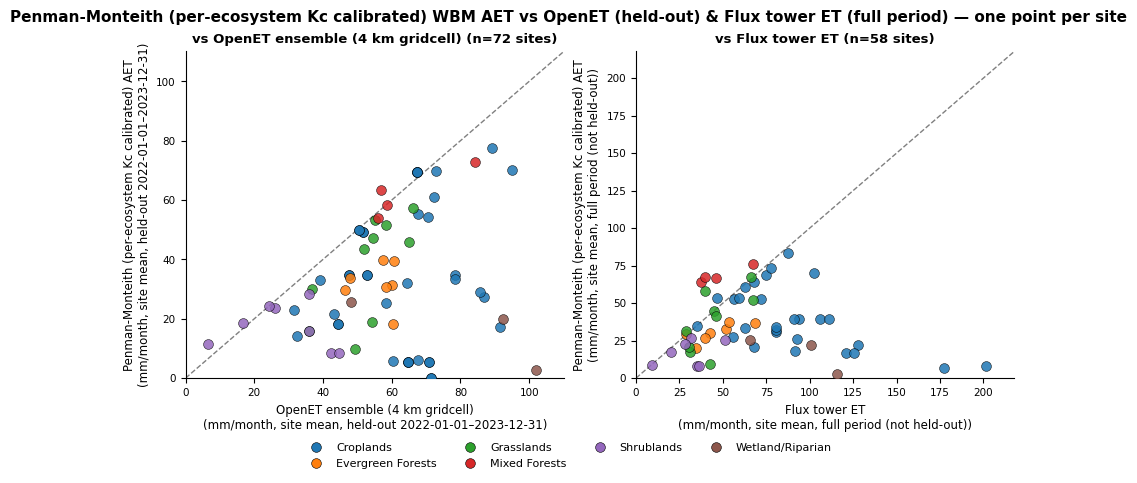

In [11]:
ecosystems_all = sorted(eco_lookup["ecosystem"].dropna().unique())
_tab_colors = plt.cm.tab10.colors
ECO_COLORS = {eco: _tab_colors[i % 10] for i, eco in enumerate(ecosystems_all)}


def _site_means(matched_df, obs_col, pred_col, metrics_df, eco_lookup):
    valid_sites = metrics_df.loc[metrics_df["note"] == "", "site"]
    return (
        matched_df[matched_df["site"].isin(valid_sites)]
        .groupby("site", as_index=False)[[obs_col, pred_col]]
        .mean()
        .merge(eco_lookup, on="site", how="left")
    )


def make_scatter_summary(openet_pts, flux_pts, obs_col_openet, obs_col_flux, pred_col, method_label):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), constrained_layout=True)
    panels = [
        (axes[0], openet_pts, obs_col_openet, "OpenET ensemble (4 km gridcell)", f"site mean, held-out {TEST_START}\u2013{TEST_END}"),
        (axes[1], flux_pts, obs_col_flux, "Flux tower ET", "site mean, full period (not held-out)"),
    ]
    for ax, pts, obs_col, ref_label, period_note in panels:
        if pts.empty:
            ax.set_visible(False)
            continue
        for eco, grp in pts.groupby("ecosystem"):
            ax.scatter(grp[obs_col], grp[pred_col], s=50, color=ECO_COLORS.get(eco, "grey"),
                       edgecolors="k", linewidths=0.4, alpha=0.85, label=eco, zorder=3)
        lims = [0, max(pts[obs_col].max(), pts[pred_col].max()) * 1.08]
        ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1, zorder=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f"{ref_label}\n(mm/month, {period_note})", fontsize=8.5)
        ax.set_ylabel(f"{method_label} AET\n(mm/month, {period_note})", fontsize=8.5)
        ax.set_title(f"vs {ref_label} (n={len(pts)} sites)", fontsize=9.5, fontweight="bold")
        ax.tick_params(labelsize=7.5)
        ax.spines[["top", "right"]].set_visible(False)
    handles = [mlines.Line2D([], [], marker="o", linestyle="", markersize=7,
                              markerfacecolor=ECO_COLORS[e], markeredgecolor="k",
                              markeredgewidth=0.4, label=e) for e in ecosystems_all]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(ecosystems_all), 4),
               bbox_to_anchor=(0.5, -0.1), fontsize=8, frameon=False)
    fig.suptitle(f"{method_label} WBM AET vs OpenET (held-out) & Flux tower ET (full period) \u2014 one point per site",
                 fontsize=11, fontweight="bold")
    plt.show()


for k in VARIANTS:
    openet_pts = _site_means(combined_test, "et_ensemble_gc_mm", PRED_COL[k], METRICS_VS_OPENET[k], eco_lookup)
    flux_pts = _site_means(combined_ts, "aet_flux_mm", PRED_COL[k], METRICS_VS_FLUX[k], eco_lookup)
    make_scatter_summary(openet_pts, flux_pts, "et_ensemble_gc_mm", "aet_flux_mm", PRED_COL[k], VARIANT_LABELS[k])

### Table 4 & Figure 4 — RMSE by ecosystem

Mean RMSE vs. OpenET (held-out), grouped by ecosystem, for all six variants.

In [12]:
eco_rmse = None
for k in VARIANTS:
    valid = METRICS_VS_OPENET[k][METRICS_VS_OPENET[k]["note"] == ""][["site", "RMSE"]].rename(columns={"RMSE": f"RMSE_{k}"})
    eco_rmse = valid if eco_rmse is None else eco_rmse.merge(valid, on="site", how="outer")
eco_rmse = eco_rmse.merge(eco_lookup, on="site", how="left")

RMSE_ECO_COLS = [f"RMSE_{k}" for k in VARIANTS]
table4 = eco_rmse.groupby("ecosystem")[RMSE_ECO_COLS].mean().round(2).reset_index()
table4.columns = ["Ecosystem"] + [VARIANT_LABELS[k] for k in VARIANTS]
table4

,Ecosystem,Oudin (default),Oudin (per-site calibrated),Oudin (per-ecosystem calibrated),Penman-Monteith (default),Penman-Monteith (per-site Kc calibrated),Penman-Monteith (per-ecosystem Kc calibrated)
0,Croplands,48.81,40.07,47.08,44.59,41.39,41.34
1,Evergreen Forests,55.75,39.81,42.86,38.86,35.22,35.98
2,Grasslands,40.81,25.71,31.07,28.03,25.86,26.21
3,Mixed Forests,55.39,22.86,43.27,28.62,27.73,27.64
4,Shrublands,19.71,19.09,21.27,23.81,18.46,19.86
5,Wetland/Riparian,76.21,76.29,76.05,78.04,76.50,76.69


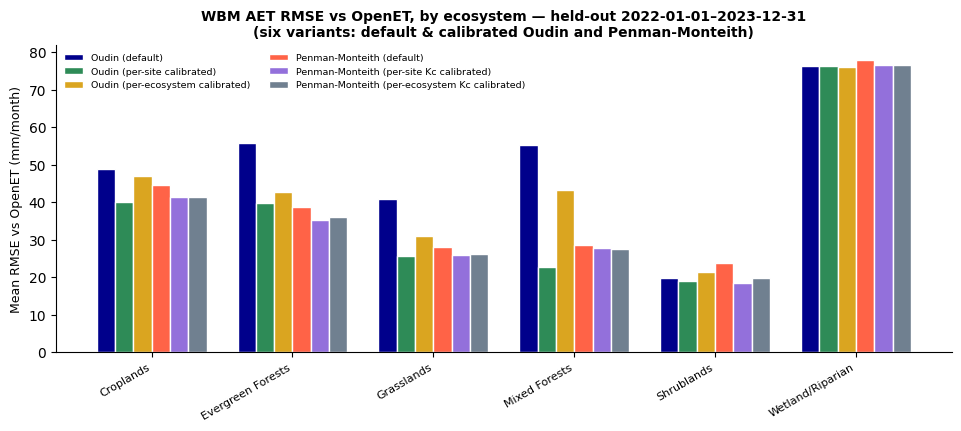

In [13]:
ecosystems = eco_rmse["ecosystem"].dropna().unique()
eco_summary = eco_rmse.groupby("ecosystem")[RMSE_ECO_COLS].mean().reset_index()
ecosystems = eco_summary["ecosystem"].tolist()
x = np.arange(len(ecosystems))
w = 0.13

fig, ax = plt.subplots(figsize=(9.5, 4.2), constrained_layout=True)
offsets = np.linspace(-2.5, 2.5, len(RMSE_ECO_COLS)) * w
for k, off in zip(VARIANTS, offsets):
    ax.bar(x + off, eco_summary[f"RMSE_{k}"], width=w, color=VARIANT_COLORS[k], label=VARIANT_LABELS[k], edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(ecosystems, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean RMSE vs OpenET (mm/month)", fontsize=9)
ax.set_title(f"WBM AET RMSE vs OpenET, by ecosystem \u2014 held-out {TEST_START}\u2013{TEST_END}\n"
             "(six variants: default & calibrated Oudin and Penman-Monteith)", fontsize=10, fontweight="bold")
ax.legend(fontsize=6.8, frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Figure 5 — Example timeseries: best / median / worst site

Ranked by held-out per-site-calibrated-Oudin RMSE vs. OpenET. Shaded region =
calibration window; dotted line = start of held-out test period.

  Best fit   : US-xJR  (RMSE=7.44 mm/month)
  Median fit : manilacotton  (RMSE=28.69 mm/month)
  Worst fit  : US-Sne  (RMSE=116.54 mm/month)


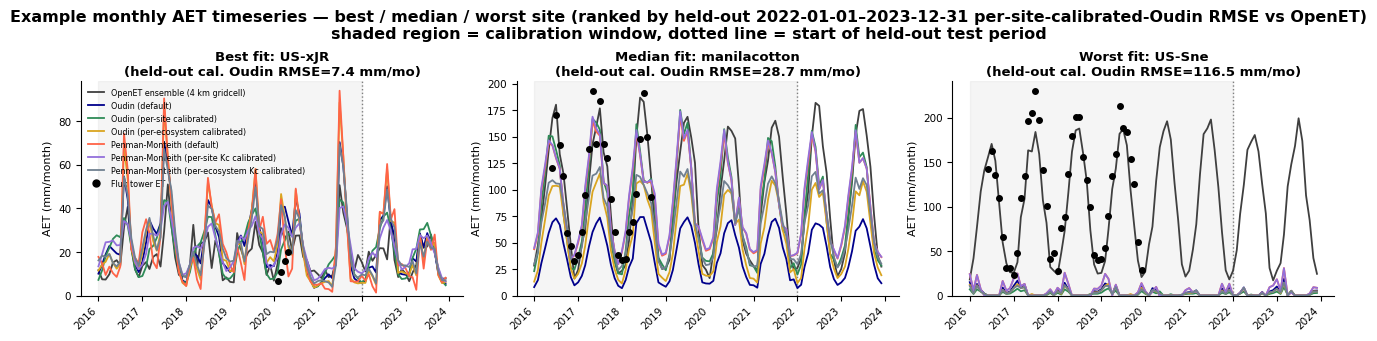

In [14]:
_valid_rank = METRICS_VS_OPENET["oudin_cal"][METRICS_VS_OPENET["oudin_cal"]["note"] == ""].sort_values("RMSE").reset_index(drop=True)
_n = len(_valid_rank)
example_sites = [
    (_valid_rank.iloc[0]["site"], "Best fit", _valid_rank.iloc[0]["RMSE"]),
    (_valid_rank.iloc[_n // 2]["site"], "Median fit", _valid_rank.iloc[_n // 2]["RMSE"]),
    (_valid_rank.iloc[-1]["site"], "Worst fit", _valid_rank.iloc[-1]["RMSE"]),
]
for site, label, rmse in example_sites:
    print(f"  {label:<10} : {site}  (RMSE={rmse:.2f} mm/month)")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=False, constrained_layout=True)
axes = np.atleast_1d(axes)
_cal_start_dt = pd.Timestamp(CAL_START)
_test_start_dt = pd.Timestamp(TEST_START)

PLOT_SPECS = [
    ("et_ensemble_gc_mm", "#3f3f3f", "OpenET ensemble (4 km gridcell)", 3),
    ("aet_oudin_mm", VARIANT_COLORS["oudin"], VARIANT_LABELS["oudin"], 4),
    ("aet_oudin_cal_mm", VARIANT_COLORS["oudin_cal"], VARIANT_LABELS["oudin_cal"], 4.5),
    ("aet_oudin_eco_cal_mm", VARIANT_COLORS["oudin_eco_cal"], VARIANT_LABELS["oudin_eco_cal"], 4.7),
    ("aet_pm_mm", VARIANT_COLORS["pm"], VARIANT_LABELS["pm"], 5),
    ("aet_pm_cal_mm", VARIANT_COLORS["pm_cal"], VARIANT_LABELS["pm_cal"], 5.2),
    ("aet_pm_eco_cal_mm", VARIANT_COLORS["pm_eco_cal"], VARIANT_LABELS["pm_eco_cal"], 5.4),
]

for ax, (site, label, rmse) in zip(axes, example_sites):
    sub = combined_ts[combined_ts["site"] == site].sort_values("date")
    ax.axvspan(_cal_start_dt, _test_start_dt, color="grey", alpha=0.08, zorder=0)
    ax.axvline(_test_start_dt, color="grey", linestyle=":", linewidth=1, zorder=2)
    for col, color, plabel, z in PLOT_SPECS:
        ax.plot(sub["date"], sub[col], color=color, linewidth=1.3, linestyle="-", label=plabel, zorder=z)
    flux_sub = sub.dropna(subset=["aet_flux_mm"])
    if not flux_sub.empty:
        ax.scatter(flux_sub["date"], flux_sub["aet_flux_mm"], color="black", s=16, zorder=8, label="Flux tower ET")
    ax.set_title(f"{label}: {site}\n(held-out cal. Oudin RMSE={rmse:.1f} mm/mo)", fontsize=9.5, fontweight="bold", pad=4)
    ax.set_ylabel("AET (mm/month)", fontsize=8)
    ax.tick_params(axis="both", labelsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

axes[0].legend(
    handles=[mlines.Line2D([], [], color=color, linewidth=1.3, label=plabel) for _, color, plabel, _ in PLOT_SPECS]
    + [mlines.Line2D([], [], color="black", linewidth=0, marker="o", markersize=5, label="Flux tower ET")],
    loc="upper left", fontsize=5.8, frameon=False,
)
fig.suptitle(
    "Example monthly AET timeseries \u2014 best / median / worst site "
    f"(ranked by held-out {TEST_START}\u2013{TEST_END} per-site-calibrated-Oudin RMSE vs OpenET)\n"
    "shaded region = calibration window, dotted line = start of held-out test period",
    fontsize=11.5, fontweight="bold",
)
plt.show()

## Part 2 — Water-balance and seasonal runoff implications

In the WBM's bucket structure, AET is the model's primary outflow competing
with runoff for the same water. The AET method choice above therefore has a
direct, mechanical consequence for simulated runoff. This section quantifies
that consequence, at both the annual and monthly-climatology scale, adapting
notebook 10's analysis directly.

### Load full-period WBM daily outputs (six variants)

Reads the same three-cache-plus-two-calibrated-PM-cache set as notebook 10,
with the same staleness auto-detection: Penman-Monteith's Kc calibration
(notebook 07) depends on wind, and its incremental caching only checks site
presence, not whether the underlying climate data changed — so a stale cache
from before a climate refetch is silently excluded rather than trusted.

In [15]:
IN_TO_MM = 25.4
COLS = ["date", "site", "ecosystem", "state", "ppt_mm", "AET", "RUNOFF"]

VARIANT_FILES = {
    "default":  "wbm_results_flux_towers_2016_2023.csv",
    "sitecal":  f"wbm_results_site_cal_{CAL_OBJECTIVE}.csv",
    "ecocal":   f"wbm_results_ecosystem_cal_{CAL_OBJECTIVE}.csv",
    "pm":       "wbm_results_penman_monteith.csv",
    "pmcal":    f"wbm_results_site_cal_pm_{CAL_OBJECTIVE_PM}.csv",
    "pmecocal": f"wbm_results_ecosystem_cal_pm_{CAL_OBJECTIVE_PM}.csv",
}
RUNOFF_VARIANT_LABELS = {
    "default":  "Oudin (default)",
    "sitecal":  f"Oudin (per-site calibrated, {CAL_OBJECTIVE})",
    "ecocal":   f"Oudin (per-ecosystem calibrated, {CAL_OBJECTIVE})",
    "pm":       "Penman-Monteith (default)",
    "pmcal":    f"Penman-Monteith (per-site Kc calibrated, {CAL_OBJECTIVE_PM})",
    "pmecocal": f"Penman-Monteith (per-ecosystem Kc calibrated, {CAL_OBJECTIVE_PM})",
}
ALT_COLORS = {
    "sitecal":  "seagreen",
    "ecocal":   "goldenrod",
    "pm":       "tomato",
    "pmcal":    "mediumpurple",
    "pmecocal": "slategrey",
}

CLIMATE_PATH = "../Data/gridmet_cache/climate_gee_flux_towers_2016_2023.csv"
_climate_mtime = os.path.getmtime(CLIMATE_PATH) if os.path.exists(CLIMATE_PATH) else 0

wbm = {}
ALTERNATIVES = ["sitecal", "ecocal", "pm"]  # always trustworthy (Oudin has no wind dependency)
for key, fname in VARIANT_FILES.items():
    fpath = f"../Data/gridmet_cache/{fname}"
    if key in ("pmcal", "pmecocal"):
        if not os.path.exists(fpath):
            print(f"NOTE -- '{RUNOFF_VARIANT_LABELS[key]}' cache not found -- excluded.")
            continue
        if os.path.getmtime(fpath) < _climate_mtime:
            print(f"WARNING -- '{RUNOFF_VARIANT_LABELS[key]}' cache predates the current "
                  "gridMET climate data -- excluded (stale Kc calibration).")
            continue
        ALTERNATIVES.append(key)

    df = pd.read_csv(fpath, usecols=COLS, parse_dates=["date"])
    for c in ("ppt_mm", "AET", "RUNOFF"):
        df[c] = df[c] * IN_TO_MM
    wbm[key] = df
    print(f"{key:10s} ({RUNOFF_VARIANT_LABELS[key]:58s}): {df.shape}")

print(f"\nVariants included in this run's comparisons: {ALTERNATIVES}")

default    (Oudin (default)                                           ): (236601, 7)
sitecal    (Oudin (per-site calibrated, peak_nse)                     ): (210312, 7)


ecocal     (Oudin (per-ecosystem calibrated, peak_nse)                ): (210312, 7)
pm         (Penman-Monteith (default)                                 ): (236601, 7)


pmcal      (Penman-Monteith (per-site Kc calibrated, peak_nse)        ): (210312, 7)
pmecocal   (Penman-Monteith (per-ecosystem Kc calibrated, peak_nse)   ): (210312, 7)

Variants included in this run's comparisons: ['sitecal', 'ecocal', 'pm', 'pmcal', 'pmecocal']


### Table 5 — Annual water-balance sensitivity

Mean annual runoff overestimate from using uncalibrated Oudin, relative to
each of the five alternatives, both nationwide and by ecosystem.

In [16]:
def mean_annual_balance(df, label):
    """Calendar-year sums per site, then averaged across years -> one row per site."""
    yearly = (
        df.assign(year=df["date"].dt.year)
        .groupby(["site", "year"], as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .sum()
    )
    return (
        yearly.groupby("site", as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .mean()
        .rename(columns={"ppt_mm": f"ppt_{label}", "AET": f"aet_{label}", "RUNOFF": f"runoff_{label}"})
    )


ann = {key: mean_annual_balance(df, key) for key, df in wbm.items()}
runoff_eco_lookup = wbm["default"][["site", "ecosystem", "state"]].drop_duplicates()

balance = ann["default"]
for key in ALTERNATIVES:
    balance = balance.merge(ann[key], on="site", how="inner")
balance = balance.merge(runoff_eco_lookup, on="site", how="left")

for label in ["default"] + ALTERNATIVES:
    resid = (balance[f"ppt_{label}"] - balance[f"aet_{label}"]) - balance[f"runoff_{label}"]
    print(f"{label:10s}: PPT - AET vs RUNOFF, mean residual = {resid.mean():+.1f} mm/yr "
          f"(median abs residual = {resid.abs().median():.1f} mm/yr, n={len(balance)} sites)")

print(f"\nSites with all {1 + len(ALTERNATIVES)} included variants matched: {len(balance)}")

default   : PPT - AET vs RUNOFF, mean residual = +16.3 mm/yr (median abs residual = 3.0 mm/yr, n=72 sites)
sitecal   : PPT - AET vs RUNOFF, mean residual = +16.0 mm/yr (median abs residual = 3.7 mm/yr, n=72 sites)
ecocal    : PPT - AET vs RUNOFF, mean residual = +16.5 mm/yr (median abs residual = 3.1 mm/yr, n=72 sites)
pm        : PPT - AET vs RUNOFF, mean residual = +16.0 mm/yr (median abs residual = 4.1 mm/yr, n=72 sites)
pmcal     : PPT - AET vs RUNOFF, mean residual = +15.3 mm/yr (median abs residual = 3.4 mm/yr, n=72 sites)
pmecocal  : PPT - AET vs RUNOFF, mean residual = +17.3 mm/yr (median abs residual = 2.4 mm/yr, n=72 sites)

Sites with all 6 included variants matched: 72


In [17]:
RUNOFF_FLOOR = 10.0  # mm/yr

for alt in ALTERNATIVES:
    balance[f"delta_runoff_{alt}"] = balance["runoff_default"] - balance[f"runoff_{alt}"]
    balance[f"pct_overest_{alt}_of_runoff"] = np.where(
        balance[f"runoff_{alt}"] >= RUNOFF_FLOOR,
        100 * balance[f"delta_runoff_{alt}"] / balance[f"runoff_{alt}"], np.nan,
    )
    balance[f"pct_overest_{alt}_of_ppt"] = 100 * balance[f"delta_runoff_{alt}"] / balance["ppt_default"].replace(0, np.nan)

table5_rows = []
for alt in ALTERNATIVES:
    d_mm = balance[f"delta_runoff_{alt}"]
    d_pctR = balance[f"pct_overest_{alt}_of_runoff"].dropna()
    d_pctP = balance[f"pct_overest_{alt}_of_ppt"]
    n_above = (balance["runoff_default"] > balance[f"runoff_{alt}"]).sum()
    table5_rows.append({
        "Switch default Oudin to": RUNOFF_VARIANT_LABELS[alt],
        "Sites overestimated (n)": f"{n_above}/{len(balance)}",
        "Mean Δrunoff (mm/yr)": round(d_mm.mean(), 1), "Median Δrunoff (mm/yr)": round(d_mm.median(), 1),
        "Mean % of alt runoff": round(d_pctR.mean(), 1), "Mean % of precip": round(d_pctP.mean(), 1),
    })
table5 = pd.DataFrame(table5_rows)
table5

,Switch default Oudin to,Sites overestimated (n),Mean Δrunoff (mm/yr),Median Δrunoff (mm/yr),Mean % of alt runoff,Mean % of precip
0,"Oudin (per-site calibrated, peak_nse)",46/72,129.2,64.7,87.5,15.7
1,"Oudin (per-ecosystem calibrated, peak_nse)",59/72,128.4,58.1,279.8,16.2
2,Penman-Monteith (default),61/72,218.8,145.9,482.2,27.3
3,"Penman-Monteith (per-site Kc calibrated, peak_...",51/72,176.4,97.2,212.2,21.0
4,"Penman-Monteith (per-ecosystem Kc calibrated, ...",59/72,165.5,82.2,204.0,21.7


### Figure 6 — Runoff overestimate by ecosystem

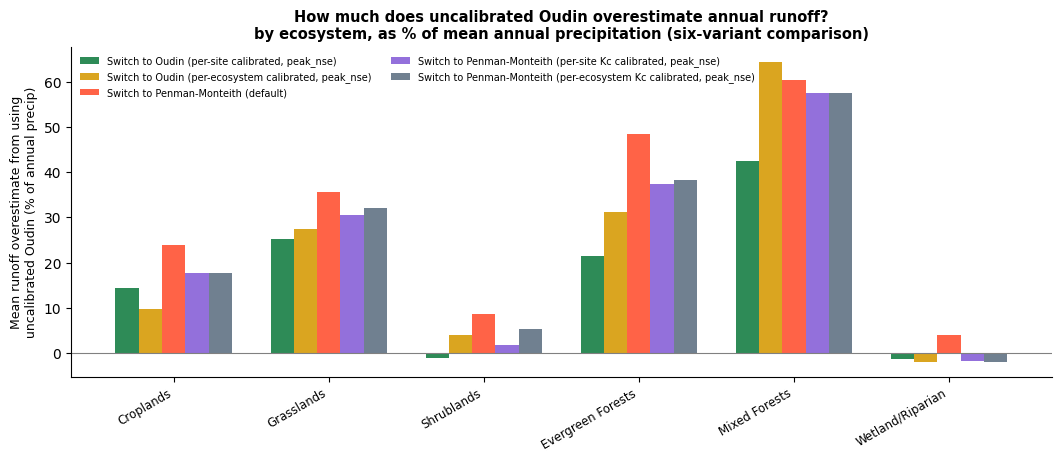

In [18]:
_included = ["default"] + ALTERNATIVES
eco_cols = (["ppt_default"] + [f"aet_{k}" for k in _included] + [f"runoff_{k}" for k in _included]
            + [f"delta_runoff_{a}" for a in ALTERNATIVES] + [f"pct_overest_{a}_of_ppt" for a in ALTERNATIVES])
eco_summary = (
    balance.groupby("ecosystem")[eco_cols].mean().round(1)
    .join(balance.groupby("ecosystem").size().rename("n_sites"))
    .reset_index().sort_values("n_sites", ascending=False)
)

x = np.arange(len(eco_summary))
w = 0.15
fig, ax = plt.subplots(figsize=(10.5, 4.5), constrained_layout=True)
offsets = np.linspace(-2, 2, len(ALTERNATIVES)) * w
for alt, off in zip(ALTERNATIVES, offsets):
    ax.bar(x + off, eco_summary[f"pct_overest_{alt}_of_ppt"], width=w, color=ALT_COLORS[alt],
           label=f"Switch to {RUNOFF_VARIANT_LABELS[alt]}")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(eco_summary["ecosystem"], rotation=30, ha="right", fontsize=8.5)
ax.set_ylabel("Mean runoff overestimate from using\nuncalibrated Oudin (% of annual precip)", fontsize=9)
ax.set_title("How much does uncalibrated Oudin overestimate annual runoff?\n"
             "by ecosystem, as % of mean annual precipitation (six-variant comparison)",
             fontsize=10.5, fontweight="bold")
ax.legend(fontsize=7, frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Figure 7 — Site-level annual runoff scatter

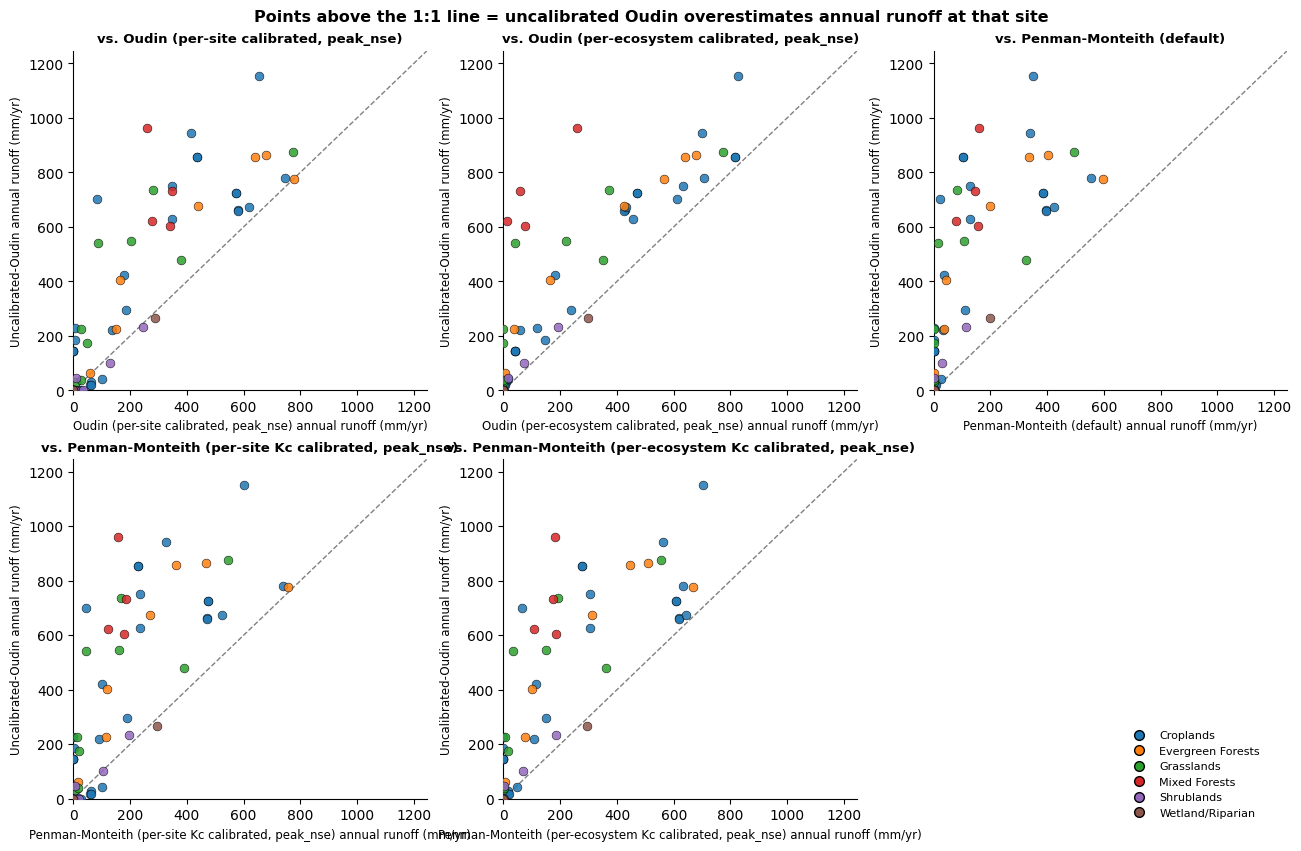

Sites where uncalibrated Oudin overestimates runoff vs. Oudin (per-site calibrated, peak_nse): 46 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Oudin (per-ecosystem calibrated, peak_nse): 59 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Penman-Monteith (default): 61 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Penman-Monteith (per-site Kc calibrated, peak_nse): 51 / 72
Sites where uncalibrated Oudin overestimates runoff vs. Penman-Monteith (per-ecosystem Kc calibrated, peak_nse): 59 / 72


In [19]:
ecosystems_all_r = sorted(balance["ecosystem"].dropna().unique())
tab_colors = plt.cm.tab10.colors
eco_colors_r = {e: tab_colors[i % 10] for i, e in enumerate(ecosystems_all_r)}

n_alt = len(ALTERNATIVES)
ncols = min(n_alt, 3)
nrows = -(-n_alt // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 4.2 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
panels = [(f"runoff_{alt}", RUNOFF_VARIANT_LABELS[alt]) for alt in ALTERNATIVES]

for ax, (col, label) in zip(axes, panels):
    for eco, grp in balance.groupby("ecosystem"):
        ax.scatter(grp[col], grp["runoff_default"], s=40, color=eco_colors_r.get(eco, "grey"),
                   edgecolors="k", linewidths=0.4, alpha=0.85, label=eco, zorder=3)
    lims = [0, max(balance[col].max(), balance["runoff_default"].max()) * 1.08]
    ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{label} annual runoff (mm/yr)", fontsize=8.5)
    ax.set_ylabel("Uncalibrated-Oudin annual runoff (mm/yr)", fontsize=8.5)
    ax.set_title(f"vs. {label}", fontsize=9.5, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_alt:]:
    ax.set_visible(False)

handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=7,
                      markerfacecolor=eco_colors_r[e], markeredgecolor="k", label=e) for e in ecosystems_all_r]
fig.legend(handles=handles, loc="lower right", ncol=1, bbox_to_anchor=(0.98, 0.02), fontsize=8, frameon=False)
fig.suptitle("Points above the 1:1 line = uncalibrated Oudin overestimates annual runoff at that site",
             fontsize=11.5, fontweight="bold")
plt.show()

for alt in ALTERNATIVES:
    n_above = (balance["runoff_default"] > balance[f"runoff_{alt}"]).sum()
    print(f"Sites where uncalibrated Oudin overestimates runoff vs. {RUNOFF_VARIANT_LABELS[alt]}: {n_above} / {len(balance)}")

### Table 6 & Figures 8–9 — Seasonality of runoff sensitivity

Does the runoff-overestimation bias track when runoff is already greatest?
Monthly climatology (calendar-month totals per site per year, averaged across
years), nationwide-mean correlation between uncalibrated Oudin's own monthly
runoff and each alternative's Δrunoff bias.

In [20]:
def monthly_climatology(df, label):
    monthly_totals = (
        df.assign(year=df["date"].dt.year, month=df["date"].dt.month)
        .groupby(["site", "year", "month"], as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .sum()
    )
    return (
        monthly_totals.groupby(["site", "month"], as_index=False)[["ppt_mm", "AET", "RUNOFF"]]
        .mean()
        .rename(columns={"ppt_mm": f"ppt_{label}", "AET": f"aet_{label}", "RUNOFF": f"runoff_{label}"})
    )


mon = {key: monthly_climatology(df, key) for key, df in wbm.items()}
monthly = mon["default"]
for key in ALTERNATIVES:
    monthly = monthly.merge(mon[key], on=["site", "month"], how="inner")
monthly = monthly.merge(runoff_eco_lookup, on="site", how="left")

for alt in ALTERNATIVES:
    monthly[f"delta_runoff_{alt}"] = monthly["runoff_default"] - monthly[f"runoff_{alt}"]
    monthly[f"delta_aet_{alt}"] = monthly[f"aet_{alt}"] - monthly["aet_default"]

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
nation_monthly = monthly.groupby("month")[
    ["runoff_default", "aet_default"] + [f"runoff_{a}" for a in ALTERNATIVES]
    + [f"aet_{a}" for a in ALTERNATIVES] + [f"delta_runoff_{a}" for a in ALTERNATIVES]
    + [f"delta_aet_{a}" for a in ALTERNATIVES]
].mean()

peak_runoff_month = MONTH_NAMES[int(nation_monthly["runoff_default"].idxmax()) - 1]
table6_rows = []
for alt in ALTERNATIVES:
    corr = nation_monthly["runoff_default"].corr(nation_monthly[f"delta_runoff_{alt}"])
    worst_m = nation_monthly[f"delta_runoff_{alt}"].idxmax()
    table6_rows.append({
        "Alternative": RUNOFF_VARIANT_LABELS[alt],
        "Correlation r (runoff magnitude vs. Δrunoff bias)": round(corr, 2),
        "Month of largest Δrunoff": MONTH_NAMES[int(worst_m) - 1],
        "Largest Δrunoff (mm/month)": round(nation_monthly[f"delta_runoff_{alt}"].max(), 1),
    })
table6 = pd.DataFrame(table6_rows)
print(f"Month with largest mean runoff (uncal. Oudin): {peak_runoff_month} "
      f"({nation_monthly['runoff_default'].max():.1f} mm/month)")
table6

Month with largest mean runoff (uncal. Oudin): May (44.3 mm/month)


,Alternative,Correlation r (runoff magnitude vs. Δrunoff bias),Month of largest Δrunoff,Largest Δrunoff (mm/month)
0,"Oudin (per-site calibrated, peak_nse)",-0.10,Aug,17.0
1,"Oudin (per-ecosystem calibrated, peak_nse)",0.39,May,13.8
2,Penman-Monteith (default),0.76,May,27.3
3,"Penman-Monteith (per-site Kc calibrated, peak_...",0.52,May,23.2
4,"Penman-Monteith (per-ecosystem Kc calibrated, ...",0.59,May,20.7


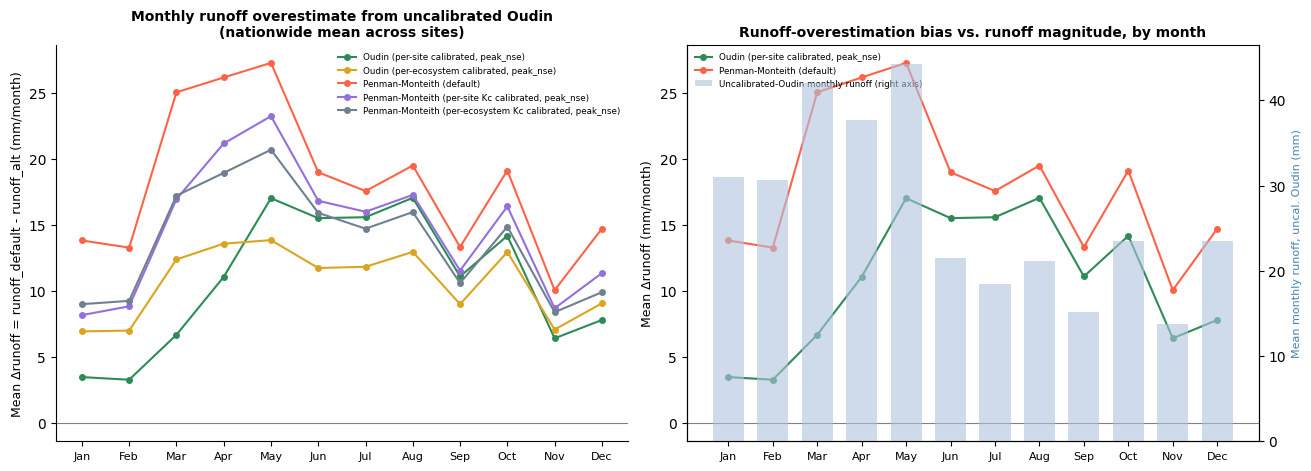

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)

ax = axes[0]
for alt in ALTERNATIVES:
    ax.plot(nation_monthly.index, nation_monthly[f"delta_runoff_{alt}"], marker="o", markersize=4,
             color=ALT_COLORS[alt], label=RUNOFF_VARIANT_LABELS[alt])
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
ax.set_ylabel("Mean Δrunoff = runoff_default - runoff_alt (mm/month)", fontsize=9)
ax.set_title("Monthly runoff overestimate from uncalibrated Oudin\n(nationwide mean across sites)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=6.3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax2 = ax.twinx()
ax2.bar(nation_monthly.index, nation_monthly["runoff_default"], color="lightsteelblue",
        alpha=0.6, width=0.7, zorder=1, label="Uncalibrated-Oudin monthly runoff (right axis)")
for alt in ("sitecal", "pm"):
    ax.plot(nation_monthly.index, nation_monthly[f"delta_runoff_{alt}"], marker="o", markersize=4,
             color=ALT_COLORS[alt], label=RUNOFF_VARIANT_LABELS[alt], zorder=3)
ax.axhline(0, color="grey", linewidth=0.8, zorder=2)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
ax.set_ylabel("Mean Δrunoff (mm/month)", fontsize=9)
ax2.set_ylabel("Mean monthly runoff, uncal. Oudin (mm)", fontsize=8, color="steelblue")
ax.set_title("Runoff-overestimation bias vs. runoff magnitude, by month", fontsize=10, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=6.3, frameon=False, loc="upper left")
ax.spines[["top"]].set_visible(False)
plt.show()

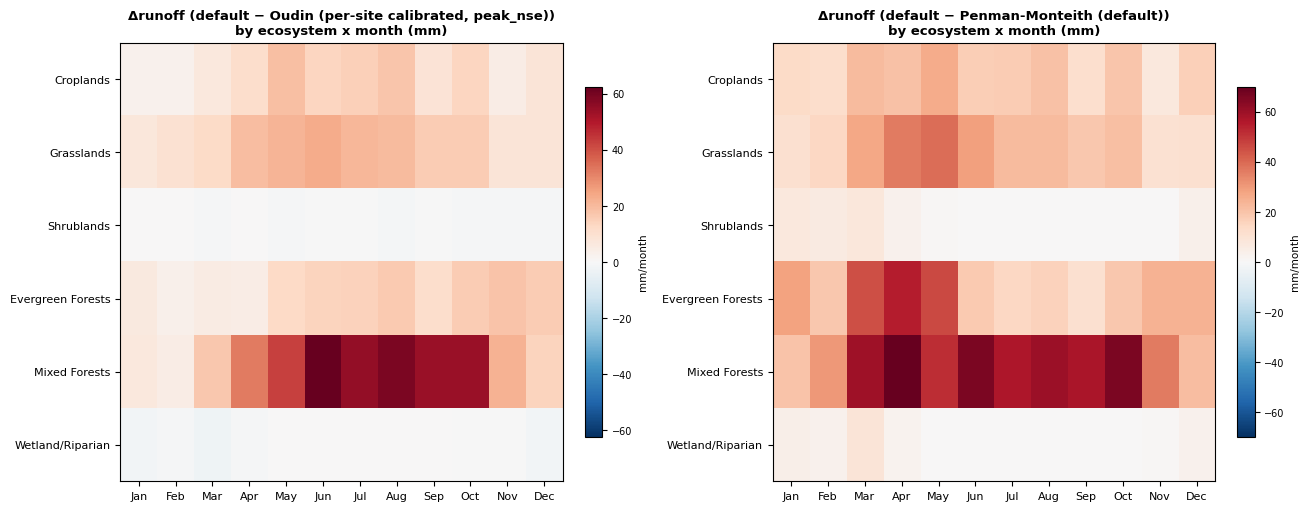

Red = uncalibrated Oudin overestimates runoff that month (positive Δrunoff); blue = it underestimates it relative to that alternative.


In [22]:
eco_month = monthly.groupby(["ecosystem", "month"])[[f"delta_runoff_{a}" for a in ALTERNATIVES]].mean().reset_index()
eco_order = eco_summary["ecosystem"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, alt in zip(axes, ("sitecal", "pm")):
    pivot = eco_month.pivot(index="ecosystem", columns="month", values=f"delta_runoff_{alt}").reindex(eco_order)
    vmax = max(abs(np.nanmin(pivot.values)), abs(np.nanmax(pivot.values)), 1)
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_yticks(range(len(eco_order))); ax.set_yticklabels(eco_order, fontsize=8)
    ax.set_title(f"Δrunoff (default − {RUNOFF_VARIANT_LABELS[alt]})\nby ecosystem x month (mm)",
                 fontsize=9.5, fontweight="bold")
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label("mm/month", fontsize=7.5)
plt.show()
print("Red = uncalibrated Oudin overestimates runoff that month (positive Δrunoff); "
      "blue = it underestimates it relative to that alternative.")

## Summary

This notebook reproduces every table and figure in `pet_comparison_report.html`
from first principles, reading only the cached WBM/OpenET/flux-tower outputs
already produced by notebooks 02–04 and 06–07 — no Earth Engine or WBM re-run
is required. Re-running this notebook end-to-end after any upstream cache is
regenerated will refresh every number and figure here to match.

Key findings (see the HTML report's Discussion/Conclusion for full narrative):
per-site-calibrated Oudin and per-site-Kc-calibrated Penman-Monteith are now
statistically tied for the best out-of-sample accuracy against OpenET; per-
ecosystem-Kc-calibrated Penman-Monteith significantly outperforms per-
ecosystem-calibrated Oudin; and switching away from uncalibrated Oudin
shrinks simulated annual runoff at most sites, with Penman-Monteith variants
concentrating that correction disproportionately in the already-highest-
runoff month (May), while per-site-calibrated Oudin spreads it more evenly
across the year.